# E-commerce A/B Testing with Revenue Forecasting

## Notebook 5: Machine Learning Models

This notebook trains machine learning forecasting models using the engineered feature table and compares them against the best baseline and classical time series models.

## Goals

1. Train machine learning forecasting models
2. Evaluate them on the same validation period
3. Compare them against Prophet and other benchmarks
4. Inspect feature importance
5. Save model results and predictions

In [1]:
# Import libraries

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [2]:
# Set display options and project paths

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path.cwd().parent
FEATURES_DIR = PROJECT_ROOT / "data" / "03-features"
PREDICTIONS_DIR = PROJECT_ROOT / "data" / "04-predictions"
MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Features dir exists:", FEATURES_DIR.exists())
print("Predictions dir exists:", PREDICTIONS_DIR.exists())
print("Models dir exists:", MODELS_DIR.exists())

Project root: c:\Users\tevin\OneDrive\Desktop\General-Machine-Learning\revenue_forecasting
Features dir exists: True
Predictions dir exists: True
Models dir exists: True


In [3]:
# Load modeling and benchmark datasets

model_df = pd.read_csv(FEATURES_DIR / "forecast_modeling_table.csv", parse_dates=["date"])
baseline_results_df = pd.read_csv(PREDICTIONS_DIR / "baseline_time_series_results.csv")
prophet_tuning_results_df = pd.read_csv(PREDICTIONS_DIR / "prophet_tuning_results.csv")

print("model_df shape:", model_df.shape)
print("baseline_results_df shape:", baseline_results_df.shape)
print("prophet_tuning_results_df shape:", prophet_tuning_results_df.shape)

model_df shape: (1654, 29)
baseline_results_df shape: (5, 4)
prophet_tuning_results_df shape: (3, 4)


## Evaluation Setup

This section defines the metric functions used to evaluate machine learning models.

In [4]:
# Define evaluation functions

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_pred[mask])) * 100

def evaluate_forecast(y_true, y_pred, model_name):
    return pd.DataFrame({
        "model": [model_name],
        "mae": [mean_absolute_error(y_true, y_pred)],
        "rmse": [rmse(y_true, y_pred)],
        "mape": [np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100]
    })

## Train and Validation Split

This section uses the same chronological split as the classical forecasting notebook.

In [5]:
# Create time-based train and validation split

model_df = model_df.sort_values("date").reset_index(drop=True)

validation_days = 90

train_df = model_df.iloc[:-validation_days].copy()
valid_df = model_df.iloc[-validation_days:].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Train max date:", train_df["date"].max())
print("Validation min date:", valid_df["date"].min())

Train shape: (1564, 29)
Validation shape: (90, 29)
Train max date: 2017-05-17 00:00:00
Validation min date: 2017-05-18 00:00:00


In [6]:
# Check available columns in model_df

model_df.columns.tolist()

['date',
 'total_sales',
 'total_onpromotion',
 'year',
 'month',
 'day_of_week',
 'day_of_week_num',
 'total_transactions',
 'dcoilwtico',
 'week_of_year',
 'is_month_start',
 'is_month_end',
 'is_holiday',
 'sales_lag_1',
 'sales_lag_7',
 'sales_lag_14',
 'sales_lag_28',
 'promo_lag_1',
 'promo_lag_7',
 'sales_roll_mean_7',
 'sales_roll_mean_14',
 'sales_roll_mean_28',
 'sales_roll_std_7',
 'sales_roll_std_14',
 'promo_roll_mean_7',
 'promo_roll_mean_14',
 'dcoilwtico_filled',
 'oil_roll_mean_7',
 'oil_roll_mean_14']

## Feature and Target Setup

This section selects the feature columns used by the machine learning models and defines the forecasting target.

In [8]:
# Define features and target

feature_cols = [
    "total_onpromotion",
    "total_transactions",
    "dcoilwtico_filled",
    "is_holiday",
    "year",
    "month",
    "day_of_week_num",
    "week_of_year",
    "is_month_start",
    "is_month_end",
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_28",
    "promo_lag_1",
    "promo_lag_7",
    "sales_roll_mean_7",
    "sales_roll_mean_14",
    "sales_roll_mean_28",
    "sales_roll_std_7",
    "sales_roll_std_14",
    "promo_roll_mean_7",
    "promo_roll_mean_14",
    "oil_roll_mean_7",
    "oil_roll_mean_14"
]

X_train = train_df[feature_cols].copy()
X_valid = valid_df[feature_cols].copy()

y_train = train_df["total_sales"].copy()
y_valid = valid_df["total_sales"].copy()

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (1564, 25)
X_valid shape: (90, 25)
y_train shape: (1564,)
y_valid shape: (90,)


## Linear Regression Baseline

This section trains a simple linear regression model as a first machine learning benchmark.

In [9]:
# Train Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_valid)

lr_results = evaluate_forecast(y_valid, lr_pred, "linear_regression")
lr_results

,model,mae,rmse,mape
0,linear_regression,51635.8906,66741.014312,6.033416


## Random Forest Model

This section trains a Random Forest regressor on the engineered features.

In [10]:
# Train Random Forest

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)

rf_results = evaluate_forecast(y_valid, rf_pred, "random_forest")
rf_results

,model,mae,rmse,mape
0,random_forest,39444.340058,53734.890817,4.523485


## XGBoost Model

This section trains an XGBoost regressor on the engineered forecasting table.

In [11]:
# Train XGBoost

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_valid)

xgb_results = evaluate_forecast(y_valid, xgb_pred, "xgboost")
xgb_results

,model,mae,rmse,mape
0,xgboost,35665.184397,52884.114952,4.005502


## Machine Learning Model Comparison

This section compares all machine learning models using the same validation metrics.

In [12]:
# Combine machine learning model results

ml_results = pd.concat(
    [lr_results, rf_results, xgb_results],
    ignore_index=True
).sort_values("rmse")

ml_results

,model,mae,rmse,mape
2,xgboost,35665.184397,52884.114952,4.005502
1,random_forest,39444.340058,53734.890817,4.523485
0,linear_regression,51635.890600,66741.014312,6.033416


## Compare ML Models Against Classical Benchmark

This section compares the machine learning results against the saved Prophet and baseline results.

In [13]:
# Compare ML models with classical benchmark

combined_results = pd.concat(
    [baseline_results_df, prophet_tuning_results_df, ml_results],
    ignore_index=True
).sort_values("rmse")

combined_results

,model,mae,rmse,mape
8,xgboost,35665.184397,52884.114952,4.005502
9,random_forest,39444.340058,53734.890817,4.523485
5,prophet_multiplicative,51598.263671,62955.223357,5.942615
10,linear_regression,51635.890600,66741.014312,6.033416
6,prophet_more_flexible,53538.724862,68885.254196,6.193390
0,prophet,50123.703649,71571.140724,5.442261
7,prophet_default_like,50123.703649,71571.140724,5.442261
1,sarimax,77766.983441,105221.559263,8.314835
2,seasonal_naive_lag_7,93934.855404,122634.696828,10.465347
3,naive_last_value,129317.639233,164712.494255,14.716884


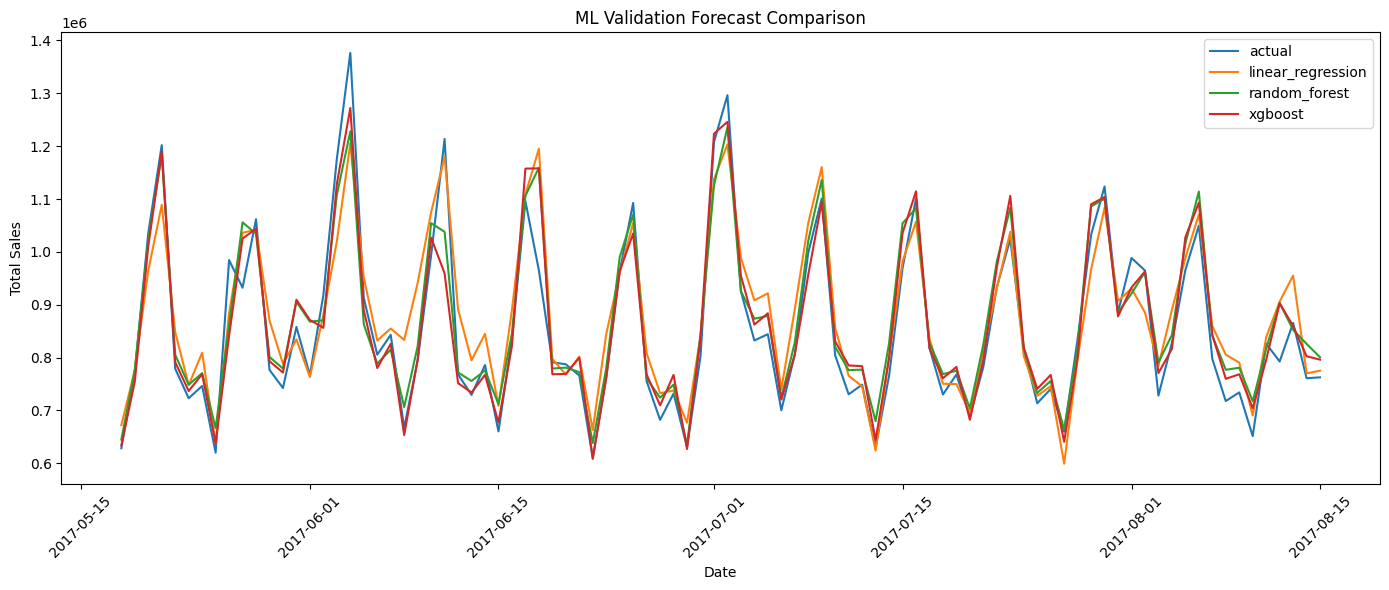

In [14]:
# Plot best ML model against actuals

best_ml_model_name = ml_results.iloc[0]["model"]

validation_plot_df = valid_df[["date", "total_sales"]].copy()
validation_plot_df["linear_regression"] = lr_pred
validation_plot_df["random_forest"] = rf_pred
validation_plot_df["xgboost"] = xgb_pred

plt.figure(figsize=(14, 6))
plt.plot(validation_plot_df["date"], validation_plot_df["total_sales"], label="actual")
plt.plot(validation_plot_df["date"], validation_plot_df["linear_regression"], label="linear_regression")
plt.plot(validation_plot_df["date"], validation_plot_df["random_forest"], label="random_forest")
plt.plot(validation_plot_df["date"], validation_plot_df["xgboost"], label="xgboost")
plt.title("ML Validation Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance

This section examines which features matter most for the strongest tree-based models.

In [15]:
# Random Forest feature importance

rf_feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

rf_feature_importance.head(15)

,feature,importance
11,sales_lag_7,0.415241
1,total_transactions,0.219113
12,sales_lag_14,0.114357
16,sales_roll_mean_7,0.092377
10,sales_lag_1,0.084931
21,promo_roll_mean_7,0.016111
13,sales_lag_28,0.012776
17,sales_roll_mean_14,0.008169
0,total_onpromotion,0.007384
6,day_of_week_num,0.006289


In [16]:
# XGBoost feature importance

xgb_feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

xgb_feature_importance.head(15)

,feature,importance
11,sales_lag_7,0.342588
12,sales_lag_14,0.143322
21,promo_roll_mean_7,0.116314
1,total_transactions,0.085360
10,sales_lag_1,0.073899
16,sales_roll_mean_7,0.056194
8,is_month_start,0.054832
17,sales_roll_mean_14,0.015883
22,promo_roll_mean_14,0.015781
6,day_of_week_num,0.014497


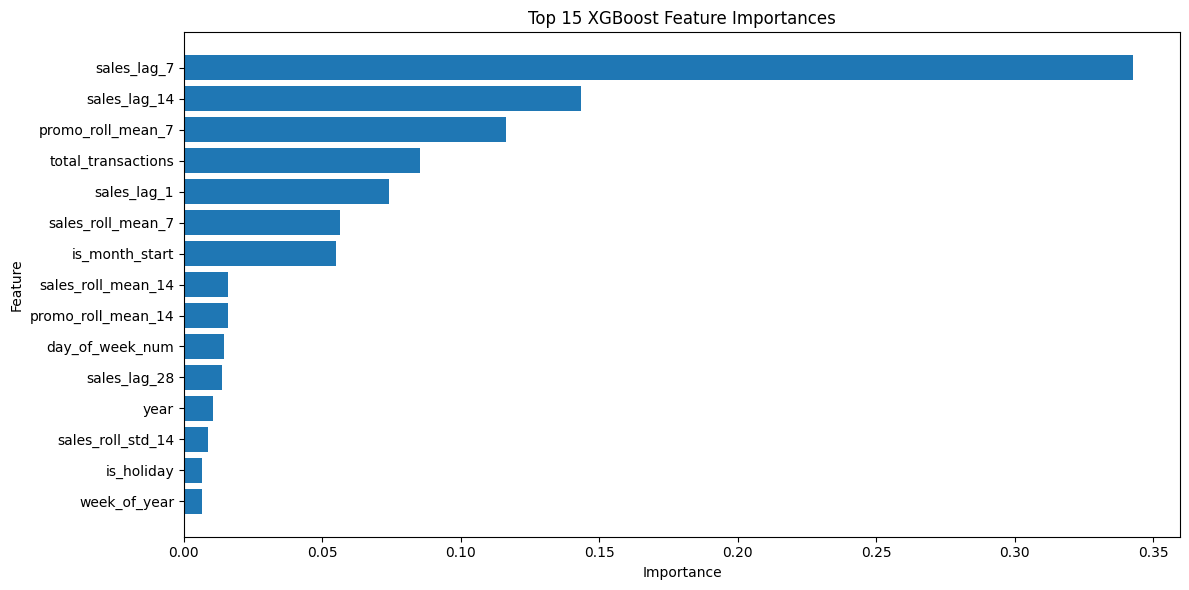

In [17]:
# Plot top XGBoost feature importances

top_xgb_features = xgb_feature_importance.head(15)

plt.figure(figsize=(12, 6))
plt.barh(top_xgb_features["feature"][::-1], top_xgb_features["importance"][::-1])
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Save Machine Learning Outputs

This section saves machine learning predictions, model comparisons, and feature importance tables.

In [19]:
# Save machine learning outputs

ml_results.to_csv(PREDICTIONS_DIR / "ml_model_results.csv", index=False)
combined_results.to_csv(PREDICTIONS_DIR / "combined_model_results.csv", index=False)
validation_plot_df.to_csv(PREDICTIONS_DIR / "ml_validation_predictions.csv", index=False)

rf_feature_importance.to_csv(PREDICTIONS_DIR / "rf_feature_importance.csv", index=False)
xgb_feature_importance.to_csv(PREDICTIONS_DIR / "xgb_feature_importance.csv", index=False)

print("Machine learning outputs saved successfully.")

Machine learning outputs saved successfully.


In [20]:
# Confirm saved machine learning files

for file in PREDICTIONS_DIR.iterdir():
    print(file.name)

baseline_time_series_results.csv
baseline_time_series_validation_predictions.csv
combined_model_results.csv
ml_model_results.csv
ml_validation_predictions.csv
prophet_diagnostics.csv
prophet_tuning_results.csv
rf_feature_importance.csv
worst_prophet_errors.csv
xgb_feature_importance.csv


## Notebook Summary

This notebook trained and evaluated:

1. Linear Regression
2. Random Forest
3. XGBoost

It compared machine learning models against the baseline and classical time series results, and identified the most important forecasting features for the strongest tree-based models.

The next notebook will connect A/B experiment uplift to revenue forecasting scenarios and business recommendations.